# Project Introduction

# Exploratory Data Analysis on Retail Sales Data

## Oasis Infobyte – Data Analytics Internship

### Objective

The objective of this project is to perform Exploratory Data Analysis (EDA) on a retail sales dataset to identify sales patterns, customer behaviour, product performance, and actionable business insights.

### Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Google Colab

### Analysis Areas

- Data inspection and cleaning
- Descriptive statistics
- Monthly and quarterly sales trends
- Customer demographics
- Product performance
- Correlation analysis
- Business insights and recommendations

# Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

# Plot style
sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


# Load the Dataset

In [ ]:
import kagglehub
path = kagglehub.dataset_download("mohammadtalib786/retail-sales-dataset")

100%|██████████| 11.2k/11.2k [00:00<00:00, 7.71MB/s]

Extracting files...


In [ ]:
import os

print("Dataset path:")
print(path)

print("\nFiles in dataset:")
print(os.listdir(path))

Dataset path:
/root/.cache/kagglehub/datasets/mohammadtalib786/retail-sales-dataset/versions/1

Files in dataset:
['retail_sales_dataset.csv']


In [ ]:
file_path= os.path.join(path, "retail_sales_dataset.csv")
df= pd.read_csv(file_path)
print("Dataset loaded successfully!")

Dataset loaded successfully!


# Initial Inspection

In [ ]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [ ]:
df.tail()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150
999,1000,2023-04-12,CUST1000,Male,47,Electronics,4,30,120


# No. of rows and columns

In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1000
Columns: 9


# Column names

In [ ]:
print("Column names:")
print(df.columns.tolist())

Column names:
['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount']


# Data types

In [ ]:
df.dtypes

,0
Transaction ID,int64
Date,object
Customer ID,object
Gender,object
Age,int64
Product Category,object
Quantity,int64
Price per Unit,int64
Total Amount,int64


# Dataset information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


# Missing values

In [ ]:
df.isnull().sum()

,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


# Duplicate records


In [ ]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


## Initial Dataset Observations

The dataset was inspected to understand its structure, number of records, column names, data types, missing values, and duplicate records.

The dataset contains transaction-level retail sales information, including customer demographics, product categories, quantity purchased, price per unit, and total transaction amount.

The missing-value and duplicate checks will help ensure that the dataset is suitable for further analysis.

# Data Cleaning

In [ ]:
# First convert the date column:
df['Date']= pd.to_datetime(df['Date'])

In [ ]:
df.dtypes

,0
Transaction ID,int64
Date,datetime64[ns]
Customer ID,object
Gender,object
Age,int64
Product Category,object
Quantity,int64
Price per Unit,int64
Total Amount,int64


In [ ]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


In [ ]:
print("Dataset shape after cleaning:", df.shape)

Dataset shape after cleaning: (1000, 9)


In [ ]:
# Dropping duplicates
df = df.drop_duplicates()

# Check numerical columns

In [ ]:
df.describe()

,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000256,41.39200,2.514000,179.890000,456.000000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632


# Descriptive Statistics

## Mean

In [ ]:

df.mean(numeric_only=True)

,0
Transaction ID,500.500
Age,41.392
Quantity,2.514
Price per Unit,179.890
Total Amount,456.000


## Median

In [ ]:
df.median(numeric_only=True)

,0
Transaction ID,500.5
Age,42.0
Quantity,3.0
Price per Unit,50.0
Total Amount,135.0


## Mode

In [ ]:
df.mode(numeric_only=True).iloc[0]

,0
Transaction ID,1.0
Age,43.0
Quantity,4.0
Price per Unit,50.0
Total Amount,50.0


## Standard deviation

In [ ]:
df.std(numeric_only=True)

,0
Transaction ID,288.819436
Age,13.681430
Quantity,1.132734
Price per Unit,189.681356
Total Amount,559.997632


## Summary table

In [ ]:
statistics= pd.DataFrame({
    'Mean': df.mean(numeric_only=True),
    'Median': df.median(numeric_only=True),
    'mode': df.mode(numeric_only=True).iloc[0],

})

statistics

,Mean,Median,mode
Transaction ID,500.500,500.5,1.0
Age,41.392,42.0,43.0
Quantity,2.514,3.0,4.0
Price per Unit,179.890,50.0,50.0
Total Amount,456.000,135.0,50.0


# Monthly Sales Analysis

In [ ]:
# Create month information
df['Month']= df['Date'].dt.to_period('M').astype(str)

In [ ]:
# Calculate monthly sales
monthly_sales= df.groupby('Month')['Total Amount'].sum()

monthly_sales

,Total Amount
Month,
2023-01,35450
2023-02,44060
2023-03,28990
2023-04,33870
2023-05,53150
2023-06,36715
2023-07,35465
2023-08,36960
2023-09,23620


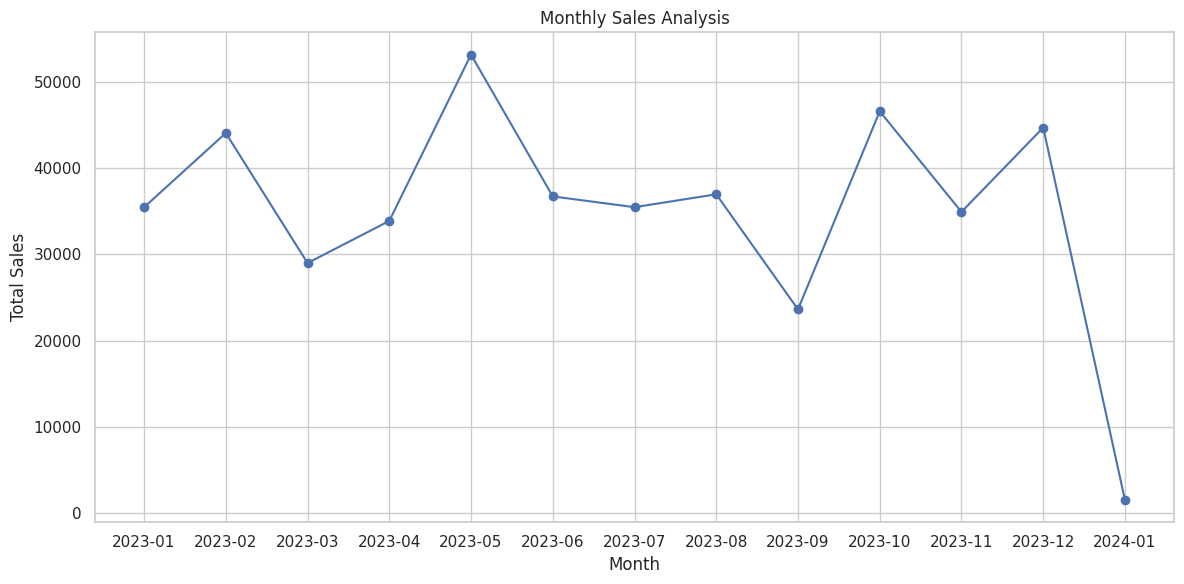

In [ ]:
# Create the line chart
plt.figure(figsize=(12, 6))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', linestyle='-', color='b')
plt.title('Monthly Sales Analysis')
plt.xlabel('Month')
plt.ylabel('Total Sales')

plt.tight_layout()
plt.show()

## Observation
### highest-sales month
### lowest-sales month
### whether sales increased/decreased
### unusual peaks

# Quarterly Sales Analysis

In [ ]:
# Create quarter
df['Quarter']= df['Date'].dt.to_period('Q').astype(str)

In [ ]:
quarterly_sales= df.groupby('Quarter')['Total Amount'].sum()
quarterly_sales

,Total Amount
Quarter,
2023Q1,108500
2023Q2,123735
2023Q3,96045
2023Q4,126190
2024Q1,1530


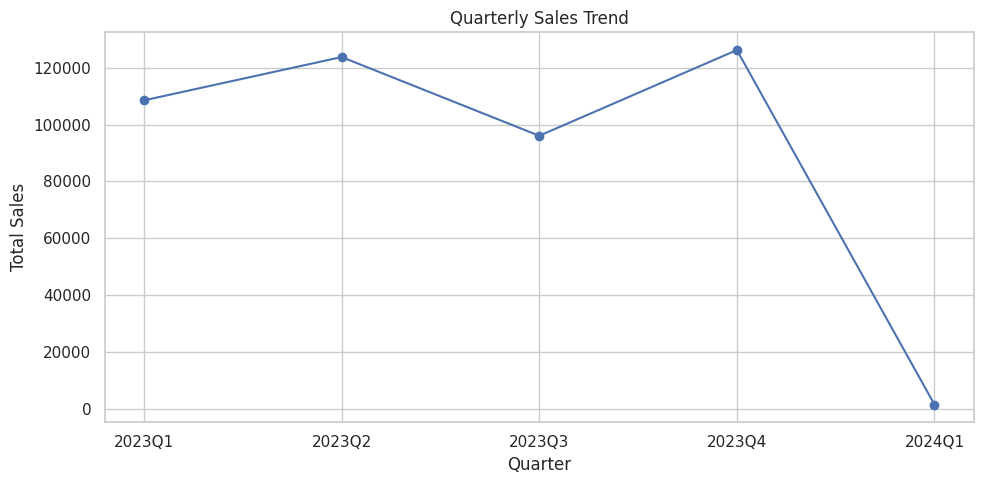

In [ ]:
# Chart
plt.figure(figsize=(10, 5))

plt.plot(
    quarterly_sales.index,
    quarterly_sales.values,
    marker='o'
)

plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')

plt.tight_layout()
plt.show()

# Customer Age Groups

In [ ]:
# Create age groups
bins=[17,27,37,47,57,67]
labels=['18-27','28-37','38-47','48-57','58-67']

df['Age Group']= pd.cut(
    df['Age'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [ ]:
# Count customers/transactions
age_group_counts= df['Age Group'].value_counts().sort_index()
age_group_counts

,count
Age Group,
18-27,214
28-37,191
38-47,222
48-57,227
58-67,146


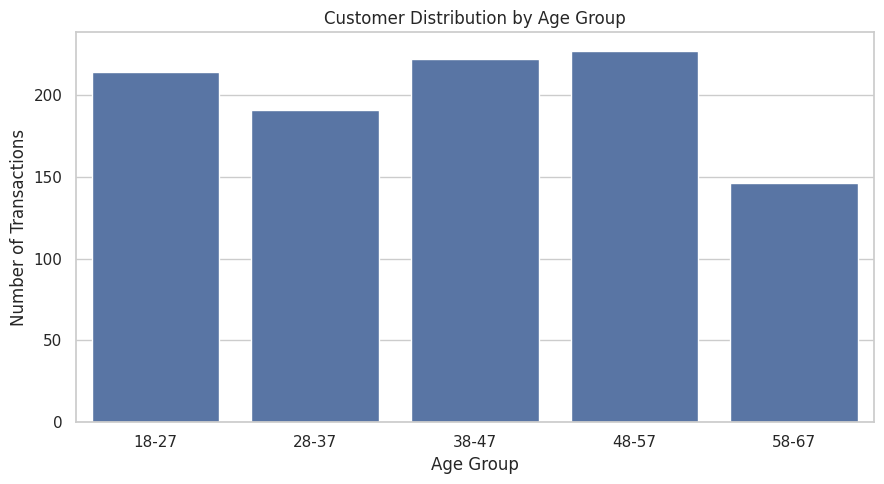

In [ ]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=age_group_counts.index,
    y=age_group_counts.values
)

plt.title('Customer Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Transactions')

plt.tight_layout()
plt.show()

# Gender Analysis

In [ ]:
gender_counts= df['Gender'].value_counts()
gender_counts

,count
Gender,
Female,510
Male,490


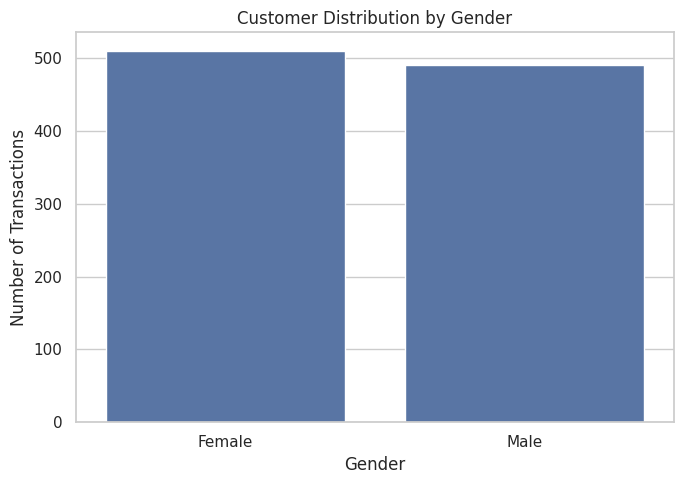

In [ ]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=gender_counts.index,
    y=gender_counts.values
)

plt.title('Customer Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Transactions')

plt.tight_layout()
plt.show()

In [ ]:
category_quantity = (
    df.groupby('Product Category')['Quantity']
    .sum()
    .sort_values(ascending=False)
)

category_quantity

,Quantity
Product Category,
Clothing,894
Electronics,849
Beauty,771


# Revenue by Product Category

In [ ]:
category_sales= (
    df.groupby('Product Category')['Total Amount']
    .sum()
    .sort_values(ascending=False)
)

category_sales

,Total Amount
Product Category,
Electronics,156905
Clothing,155580
Beauty,143515


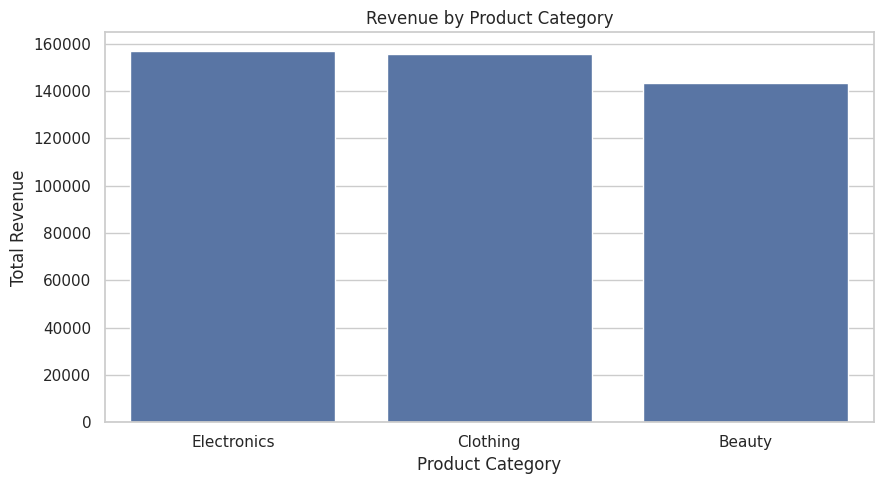

In [ ]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)

plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')

plt.tight_layout()
plt.show()

# Correlation Heatmap

In [ ]:
numeric_columns= [
    'Age',
    'Quantity',
    'Price per Unit',
    'Total Amount'
]

correlation_matrix= df[numeric_columns].corr()
correlation_matrix

,Age,Quantity,Price per Unit,Total Amount
Age,1.000000,-0.023737,-0.038423,-0.060568
Quantity,-0.023737,1.000000,0.017501,0.373707
Price per Unit,-0.038423,0.017501,1.000000,0.851925
Total Amount,-0.060568,0.373707,0.851925,1.000000


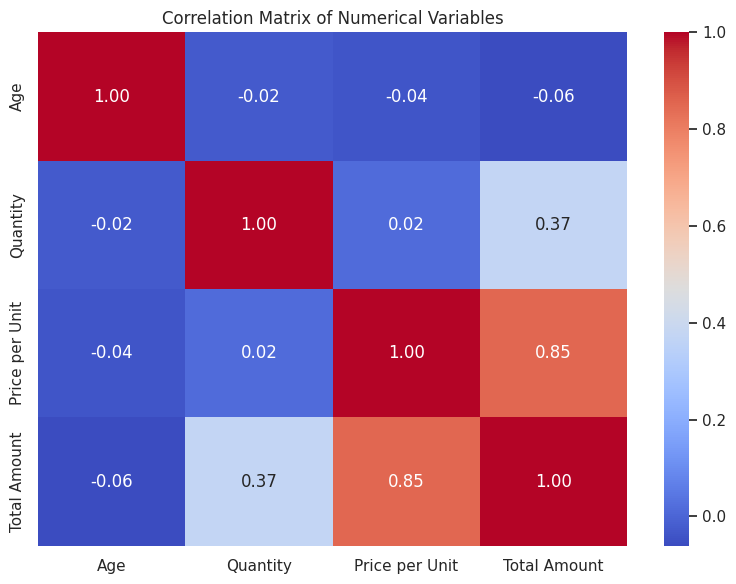

In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix of Numerical Variables')

plt.tight_layout()
plt.show()

# Additional Visualization

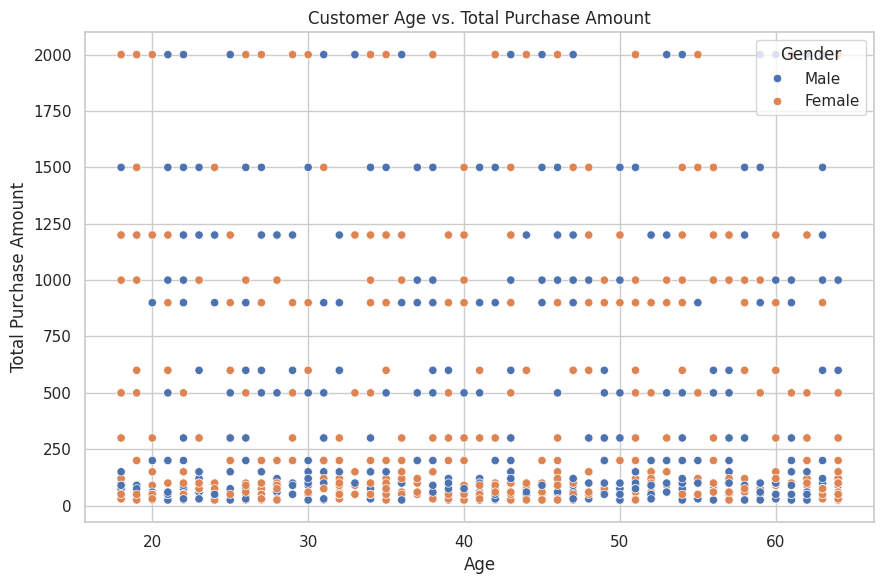

In [ ]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x='Age',
    y='Total Amount',
    hue='Gender'
)

plt.title('Customer Age vs. Total Purchase Amount')
plt.xlabel('Age')
plt.ylabel('Total Purchase Amount')

plt.tight_layout()
plt.show()

## Key Findings

Based on the exploratory analysis:

1. The monthly sales analysis shows **May 2023 recorded the highest monthly sales, while September 2023 recorded the lowest sales**.
2. The quarterly sales analysis shows **Q4 2023 recorded the highest quarterly sales, followed by Q2**.
3. The most represented customer age group is **48–57 years**.
4. The gender analysis shows **a nearly balanced distribution, with female customers accounting for 51% and male customers accounting for 49% of transactions**.
5. **Electronics** is the highest-revenue product category.
6. The correlation analysis indicates **a strong positive relationship between Price per Unit and Total Amount, with a correlation of approximately 0.85**.
7. The age vs. purchase analysis suggests **a very weak relationship between customer age and purchase amount**.

## Conclusion

This exploratory data analysis provided useful insights into retail sales trends, customer demographics, and product-category performance.

The analysis covered data inspection and cleaning, descriptive statistics, monthly and quarterly sales trends, customer demographic analysis, product-category analysis, correlation analysis, and visualization.

The findings showed that sales varied across different months and quarters, Electronics generated the highest revenue among the product categories, and customer transactions were relatively balanced between male and female customers. The correlation analysis also indicated a strong positive relationship between Price per Unit and Total Amount, while customer age showed a very weak relationship with purchase amount.

These insights can help businesses understand customer purchasing behaviour, identify high-performing product categories, recognize sales patterns, and support data-driven decisions related to marketing, inventory, and sales strategies.